## Assigmnet 1 - Erling

### Imports

In [3]:
# Import pandas for data handling and matplotlib for plotting
import pandas as pd
import matplotlib.pyplot as plt

### Read the reservoirs.csv

In [4]:
df = pd.read_csv("reservoirs.csv", parse_dates=["dato_Id"]) # Read the CSV file and interpret the "dato_Id" column as dates
print(df.shape)
df.head()  # Preview 

(14877, 11)


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


### Rename headers to English and understandable

In [5]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "unique_values": df.nunique()
})
summary # Print a summary over the data types and the number of unique values in each column

,dtype,unique_values
dato_Id,datetime64[us],1653
omrType,str,3
omrnr,int64,6
iso_aar,int64,32
iso_uke,int64,53
fyllingsgrad,float64,14868
kapasitet_TWh,float64,9
fylling_TWh,float64,14871
neste_Publiseringsdato,str,396
fyllingsgrad_forrige_uke,float64,14868


In [6]:
df = df.rename(columns={
    "omrType": "area_type",                               # 3 typs of area, "EL", "VASS" AND "NO"
    "omrnr": "area_number",                               # EL is split into 5 different electrical pricing zones,
    # VASS is split into 3 differnt draining regions and  NO is the hole conttry under 1
    "iso_aar": "iso_year",                                # data year in ISO format
    "iso_uke": "iso_week",                                # data week in ISO format
    "fyllingsgrad": "fill_degree",                        # reservoir fill degree (0-1 fraction)
    "kapasitet_TWh": "capacity_twh",                      # total capacity in TWh
    "fylling_TWh": "filling_twh",                         # actual stored energy in TWh
    "neste_Publiseringsdato": "next_publish_date",        # next publication date
    "fyllingsgrad_forrige_uke": "fill_degree_prev_week",  # fill degree from previous week
    "endring_fyllingsgrad": "fill_degree_change",         # change in fill degree
})
df.head()

,dato_Id,area_type,area_number,iso_year,iso_week,fill_degree,capacity_twh,filling_twh,next_publish_date,fill_degree_prev_week,fill_degree_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


### Print its contents in a relevant way

As it is now, each week contains 9 datapoints, representing sum of all reservoirs within each price zone and sum of all reservoirs within each drainage course, and a sum of Norway in total. 

We will derfor chose to filter out anything that is not "area_type"== "NO", meaning we will focus on Norway in total

In [7]:

national = df[df["area_type"] == "NO"].copy()

# Sort by date and use the date as the index, since this is time series data
national = national.sort_values("dato_Id").set_index("dato_Id")
national.head()

,area_type,area_number,iso_year,iso_week,fill_degree,capacity_twh,filling_twh,next_publish_date,fill_degree_prev_week,fill_degree_change
dato_Id,,,,,,,,,,
1995-01-08,NO,0,1995,1,0.608274,87.43758,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
1995-01-15,NO,0,1995,2,0.582372,87.43758,50.921207,0001-01-01T00:00:00,0.608274,-0.025902
1995-01-22,NO,0,1995,3,0.562412,87.43758,49.175980,0001-01-01T00:00:00,0.582390,-0.019977
1995-01-29,NO,0,1995,4,0.534508,87.43758,46.736122,0001-01-01T00:00:00,0.562412,-0.027904
1995-02-05,NO,0,1995,5,0.506486,87.43758,44.285900,0001-01-01T00:00:00,0.534489,-0.028003


In [8]:
# Print the shape (rows, columns) and summary information about the dataset
print(national.shape)
national.info()        # Data types and non-null counts for each column
national.describe()    # Summary statistics (mean, std, min, max, etc.)

(1653, 10)
<class 'pandas.DataFrame'>
DatetimeIndex: 1653 entries, 1995-01-08 to 2026-09-06
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area_type              1653 non-null   str    
 1   area_number            1653 non-null   int64  
 2   iso_year               1653 non-null   int64  
 3   iso_week               1653 non-null   int64  
 4   fill_degree            1653 non-null   float64
 5   capacity_twh           1653 non-null   float64
 6   filling_twh            1653 non-null   float64
 7   next_publish_date      1653 non-null   str    
 8   fill_degree_prev_week  1653 non-null   float64
 9   fill_degree_change     1653 non-null   float64
dtypes: float64(5), int64(3), str(2)
memory usage: 176.4 KB


,area_number,iso_year,iso_week,fill_degree,capacity_twh,filling_twh,fill_degree_prev_week,fill_degree_change
count,1653.0,1653.000000,1653.000000,1653.000000,1653.00000,1653.000000,1653.000000,1653.000000
mean,0.0,2010.346038,26.405929,0.622086,87.43758,54.393716,0.622156,-0.000070
std,0.0,9.149156,15.021950,0.195967,0.00000,17.134922,0.195992,0.027704
min,0.0,1995.000000,1.000000,0.180250,87.43758,15.760602,0.180260,-0.144430
25%,0.0,2002.000000,13.000000,0.460607,87.43758,40.274364,0.460607,-0.022063
50%,0.0,2010.000000,26.000000,0.645902,87.43758,56.476093,0.647445,-0.005650
75%,0.0,2018.000000,39.000000,0.789274,87.43758,69.012170,0.789271,0.016337
max,0.0,2026.000000,53.000000,0.966916,87.43758,84.544820,0.966892,0.125069


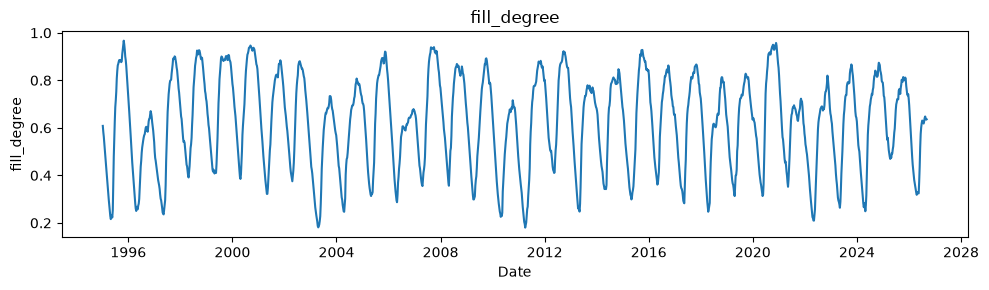

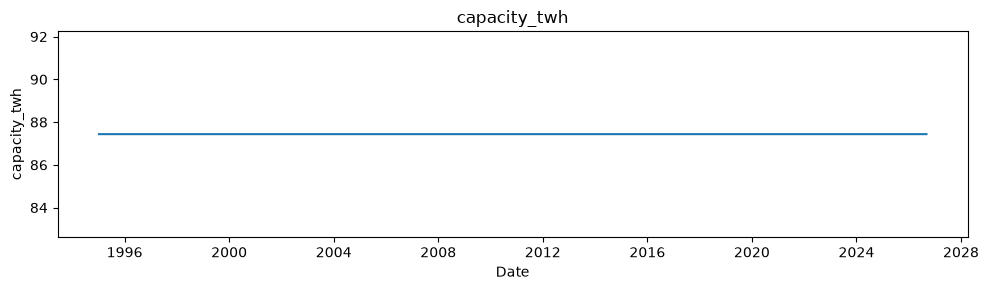

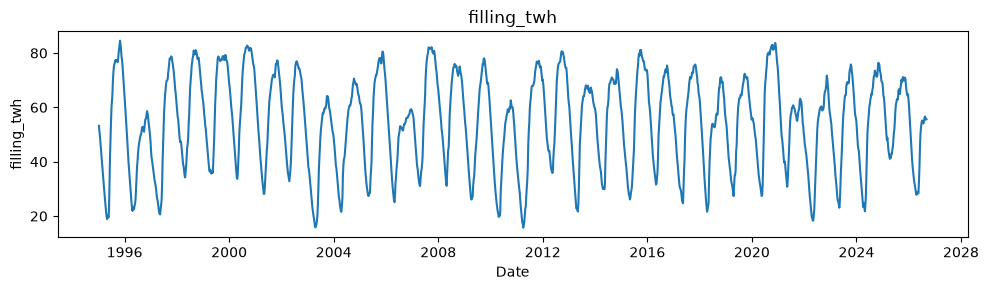

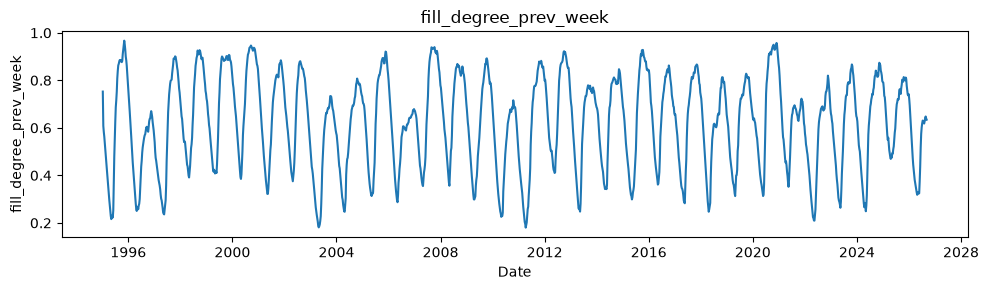

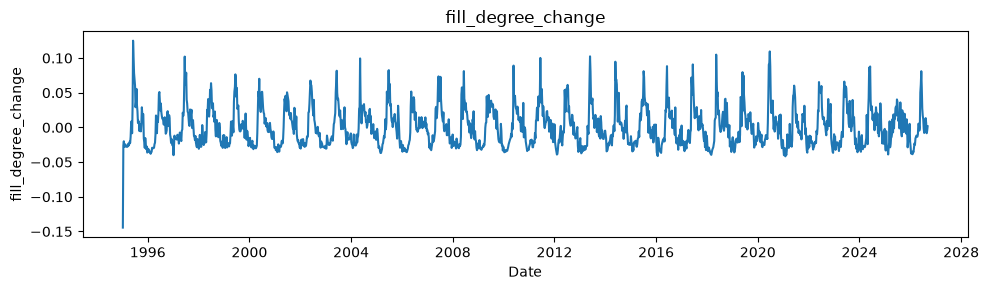

In [9]:
# The numeric columns we want to visualize
numeric_cols = ["fill_degree", "capacity_twh", "filling_twh",
                 "fill_degree_prev_week", "fill_degree_change"]

# Plot each column in its own separate figure, since they have very
# different scales and units (a fraction vs. TWh values)
for col in numeric_cols:
    plt.figure(figsize=(10, 3))
    plt.plot(national.index, national[col])
    plt.title(col)
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Plot all columns together

The columns has very different scales. The most natural way before plotting each column on the same axis would be normalizing. 

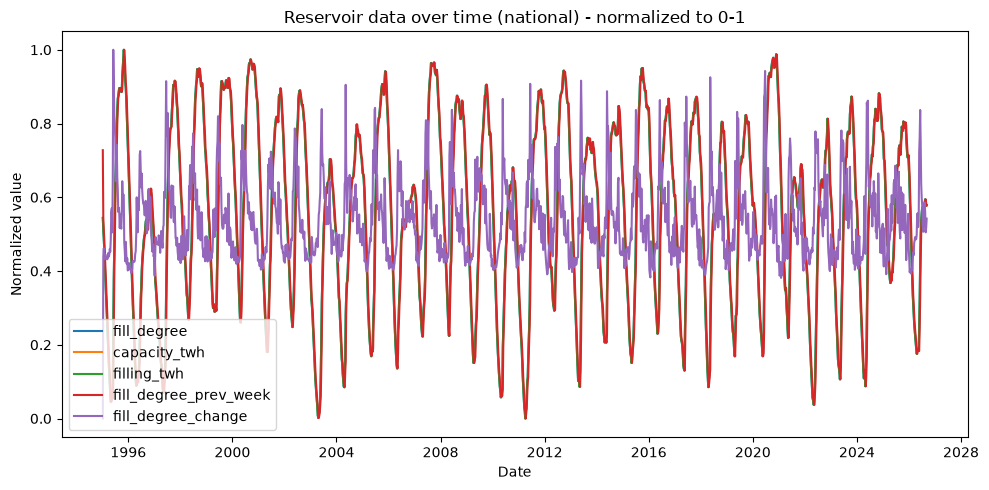

In [ ]:
# Normalize the numeric columns to a 0-1 range using min-max scaling
normalized = (national[numeric_cols] - national[numeric_cols].min()) / (national[numeric_cols].max() - national[numeric_cols].min())

# Plot the normalized data on a shared axis
plt.figure(figsize=(10, 5))
for col in numeric_cols:
    plt.plot(normalized.index, normalized[col], label=col)
plt.title("Reservoir data over time (national) - normalized to 0-1")
plt.xlabel("Date")
plt.ylabel("Normalized value")
plt.legend()
plt.tight_layout()
plt.show()

# Comment on plot

capacity_twh, filling_twh, fill_degree_prev_week, and fill_degree are
moving together and overlapping, which makes total sense because they are
all closely related to the same underlying quantity (how full the reservoirs
are), especially after normalizing. fill_degree_change, on the other hand,
moves independently of the rest. This is because it represents the
week-over-week change in fill degree rather than a fill level itself — so
instead of a smooth seasonal curve like the others, it fluctuates rapidly
around zero, reflecting short-term ups and downs rather than the overall
long-term trend.